Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/stud.csv")
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

In [6]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
#Check the null values and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

**INSIGHTS**

1.From above description of numerical data, all means are very close to each other - between 66 and 68.05.
2.All standard deviations are also close - between 14.6 and 15.19;
3.While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading   higher = 17

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
print(f"Categories in gender feature :\n")
print(df.gender.unique(),"\n")
print(f"Categories in the race_ethinicity feature :\n")
print(df.race_ethnicity.unique(),"\n")
print(f"Categories in the parental_level_of_education feature :\n")
print(df.parental_level_of_education.unique(),"\n")
print(f"Categories in the lunch feature :\n")
print(df.lunch.unique(),"\n")
print(f"Categories in the test_preparation_course :\n")
print(df.test_preparation_course.unique())

Categories in gender feature :

<StringArray>
['female', 'male']
Length: 2, dtype: str 

Categories in the race_ethinicity feature :

<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str 

Categories in the parental_level_of_education feature :

<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str 

Categories in the lunch feature :

<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str 

Categories in the test_preparation_course :

<StringArray>
['none', 'completed']
Length: 2, dtype: str


In [17]:
numeric_features = df.select_dtypes(include=["number"]).columns
categorical_features = df.select_dtypes(include=["object"]).columns

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : Index(['math_score', 'reading_score', 'writing_score'], dtype='str')

We have 5 categorical features : Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')


In [18]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [19]:
#Adding the columns for total score and the average

df["total_score"] = df["math_score"]+df["reading_score"]+df["writing_score"]
df["average_score"] = df["total_score"]/3

In [20]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [26]:
reading_full = df[df['reading_score'] == 100]["average_score"].count()
writing_full = df[df['writing_score'] == 100]["average_score"].count()
math_full = df[df['math_score'] == 100]["average_score"].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [28]:
df.corr(numeric_only=True)

,math_score,reading_score,writing_score,total_score,average_score
math_score,1.000000,0.817580,0.802642,0.918746,0.918746
reading_score,0.817580,1.000000,0.954598,0.970331,0.970331
writing_score,0.802642,0.954598,1.000000,0.965667,0.965667
total_score,0.918746,0.970331,0.965667,1.000000,1.000000
average_score,0.918746,0.970331,0.965667,1.000000,1.000000


In [29]:
reading_full = df[df['reading_score'] <= 20]["average_score"].count()
writing_full = df[df['writing_score'] <= 20]["average_score"].count()
math_full = df[df['math_score'] <= 20]["average_score"].count()

print(f'Number of students with poor marks in Maths: {math_full}')
print(f'Number of students with poor marks in Writing: {writing_full}')
print(f'Number of students with poor marks in Reading: {reading_full}')

Number of students with poor marks in Maths: 4
Number of students with poor marks in Writing: 3
Number of students with poor marks in Reading: 1


**INSIGHTS :-**

1. Students has performed worst in the maths 
2. Students has performed well in the reading_section

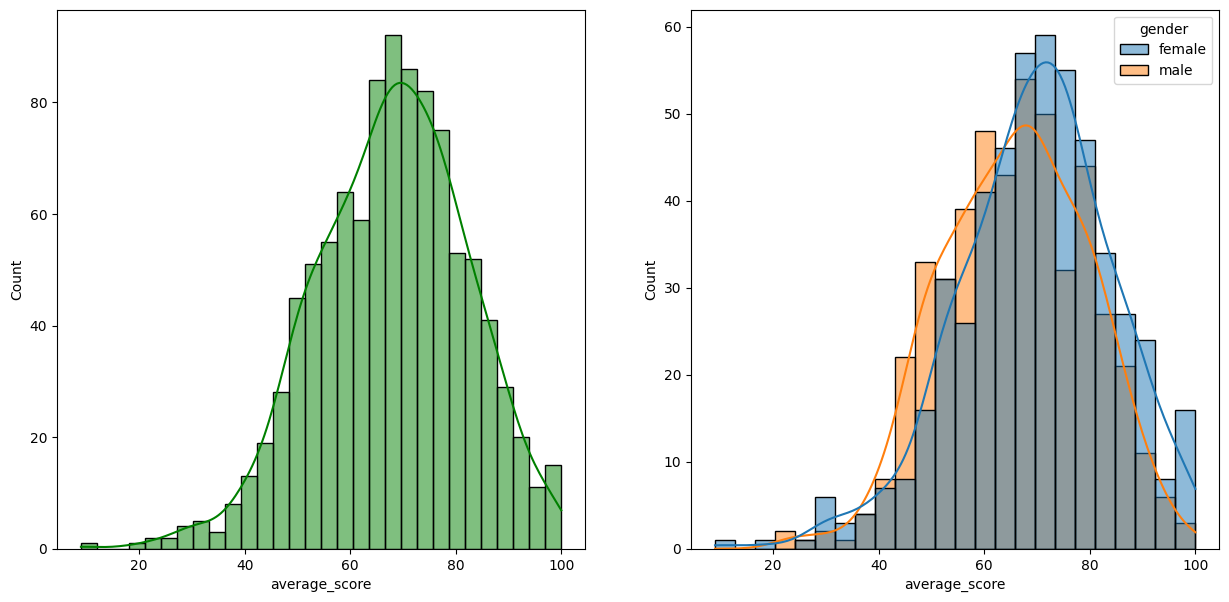

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.show()

<Axes: xlabel='average_score', ylabel='Density'>

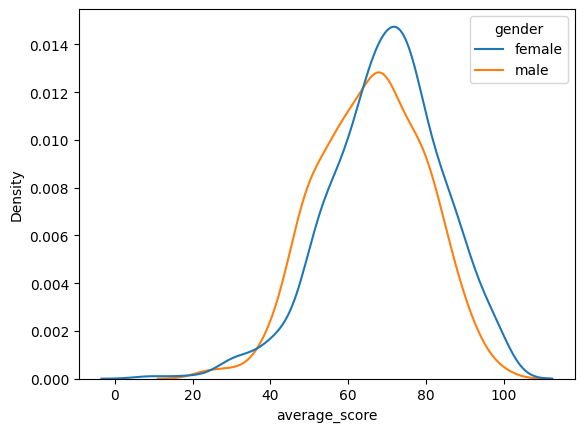

In [41]:
sns.kdeplot(data=df, x="average_score", hue="gender")

<Axes: xlabel='total_score', ylabel='Density'>

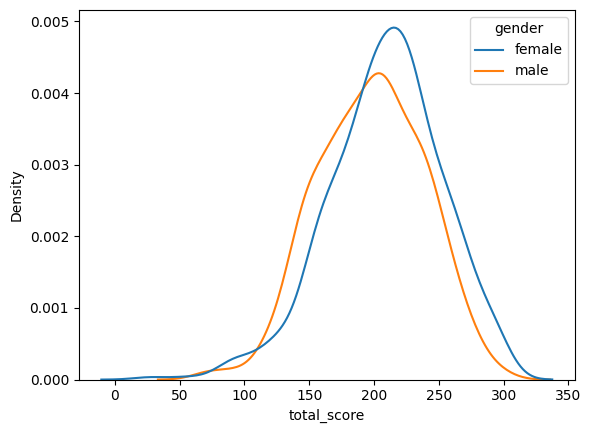

In [45]:
sns.kdeplot(data=df, x="total_score", hue="gender")

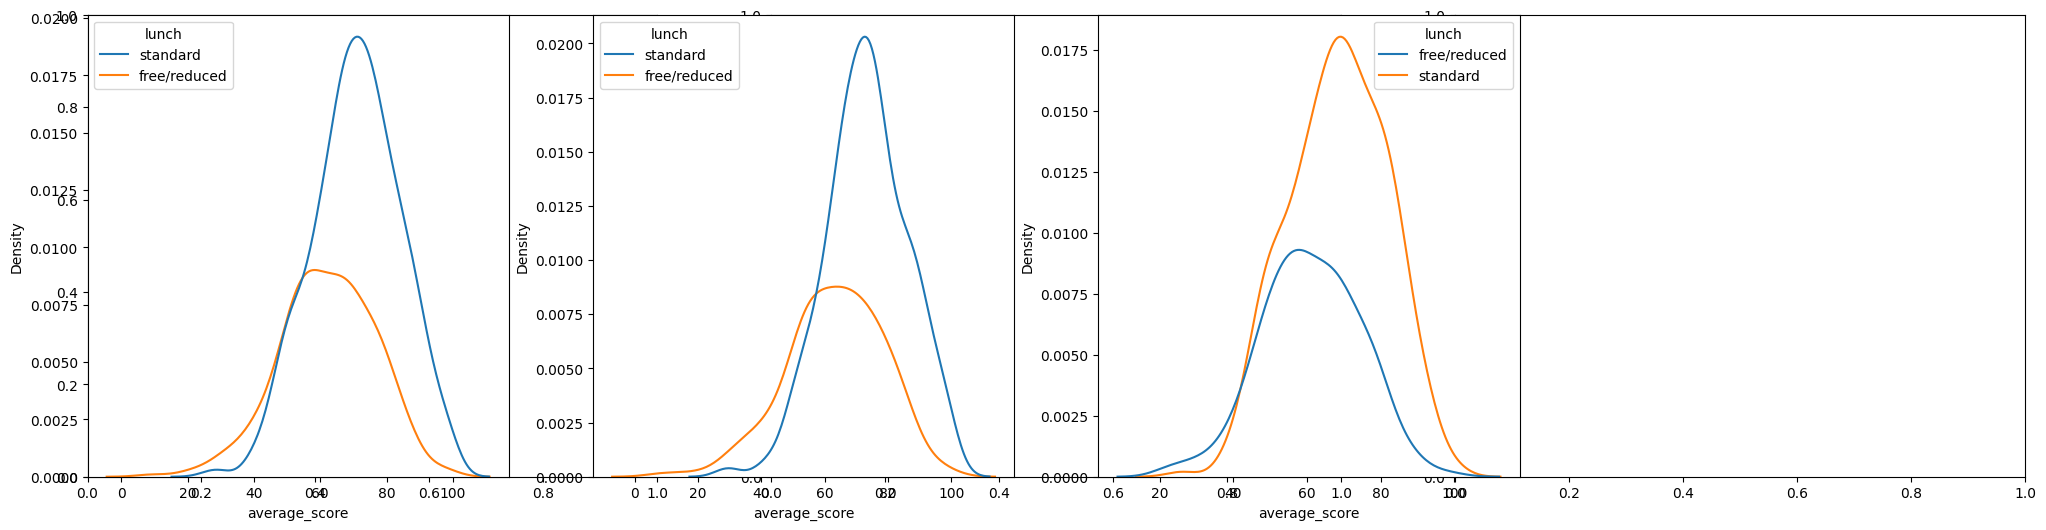

In [55]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.kdeplot(data=df,x='average_score',hue='lunch')
plt.subplot(142)
sns.kdeplot(data=df[df.gender=='female'],x='average_score',hue='lunch')
plt.subplot(143)
sns.kdeplot(data=df[df.gender=='male'],x='average_score',hue='lunch')
plt.show()

In [57]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score'],
      dtype='str')

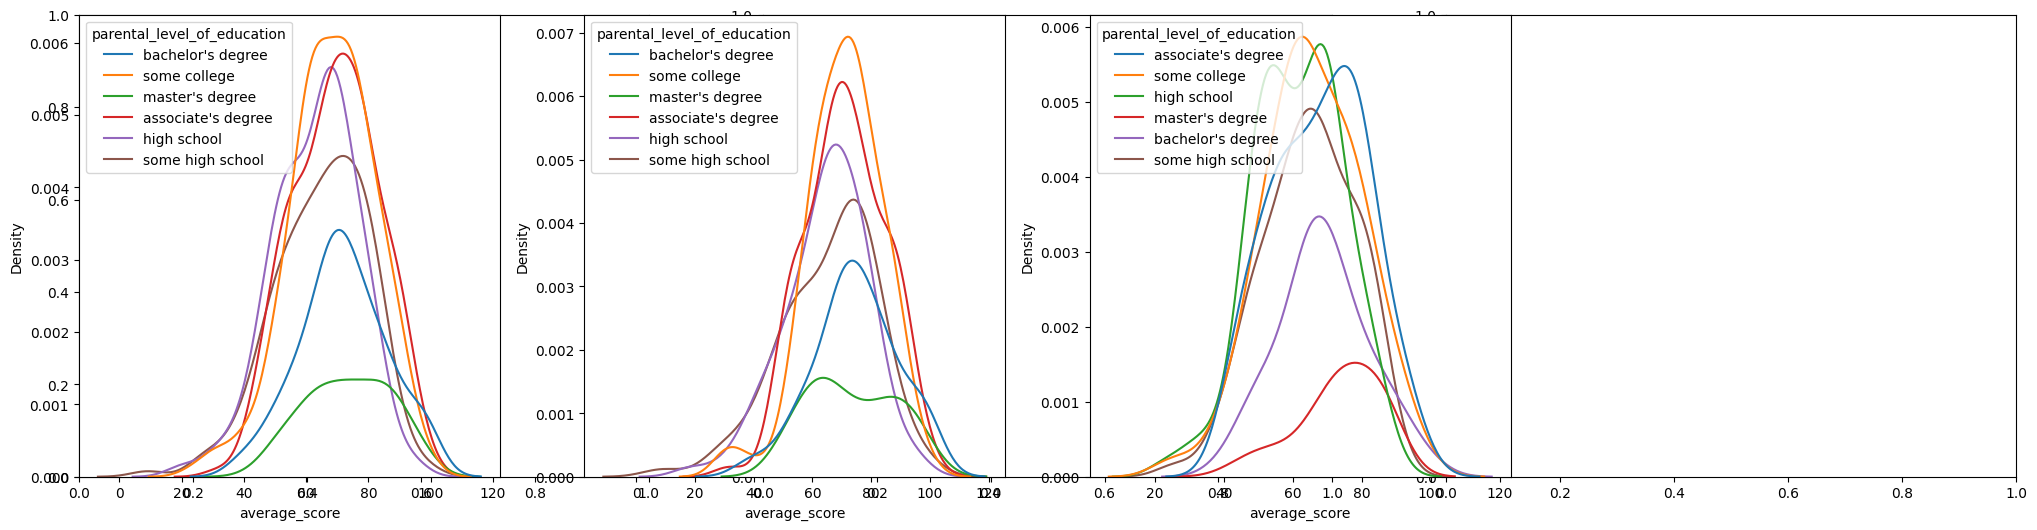

In [58]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.kdeplot(data=df,x='average_score',hue='parental_level_of_education')
plt.subplot(142)
sns.kdeplot(data=df[df.gender=='female'],x='average_score',hue='parental_level_of_education')
plt.subplot(143)
sns.kdeplot(data=df[df.gender=='male'],x='average_score',hue='parental_level_of_education')
plt.show()

**INSIGHTS :-**

1. 1ST plot says parents education doesn't have the any general effect on the student.
2. 2nd plot says that parents education with some college and the associate's degree have the better effect overall on the male students. 
3. 3rd plot also says no effect

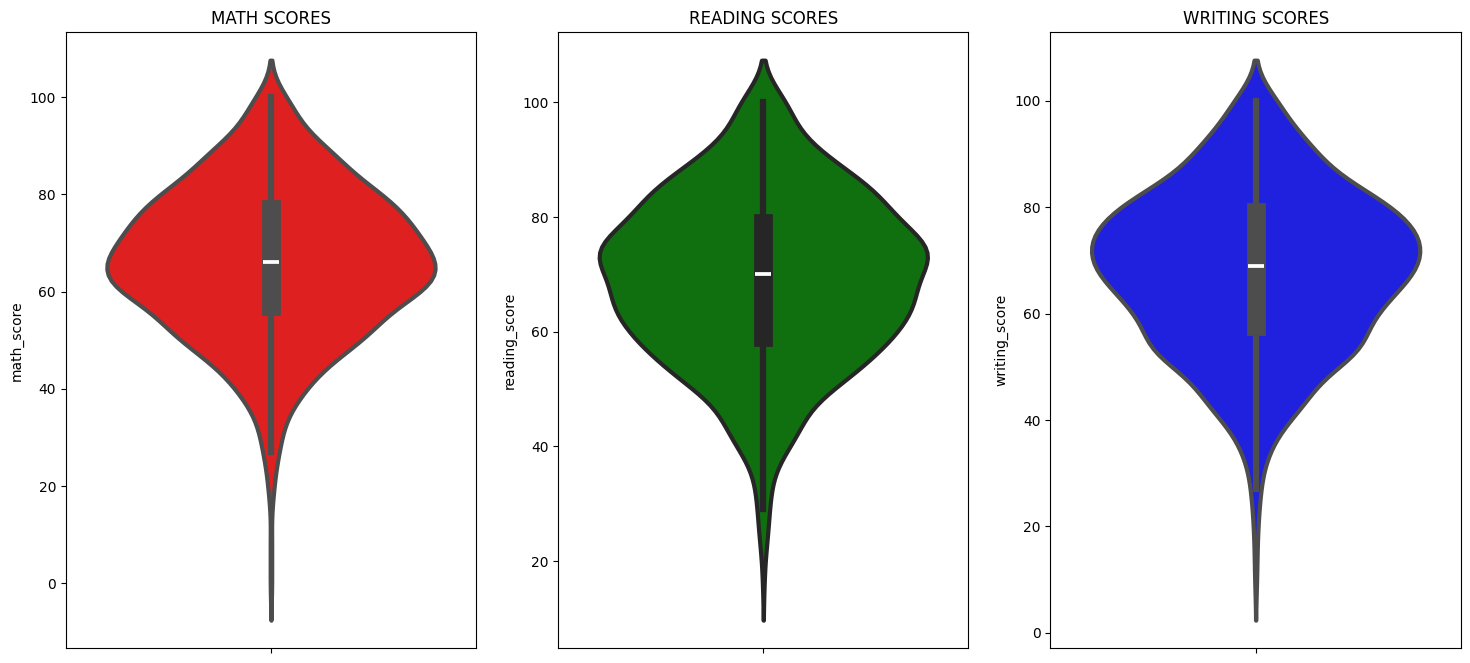

In [60]:
plt.figure(figsize=(18,8))
plt.subplot(1, 3, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 3, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 3, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

**INSIGHTS :-**

1. Maths students mostly have score between the 60-80.
2. For rest the score is between the 50-80.

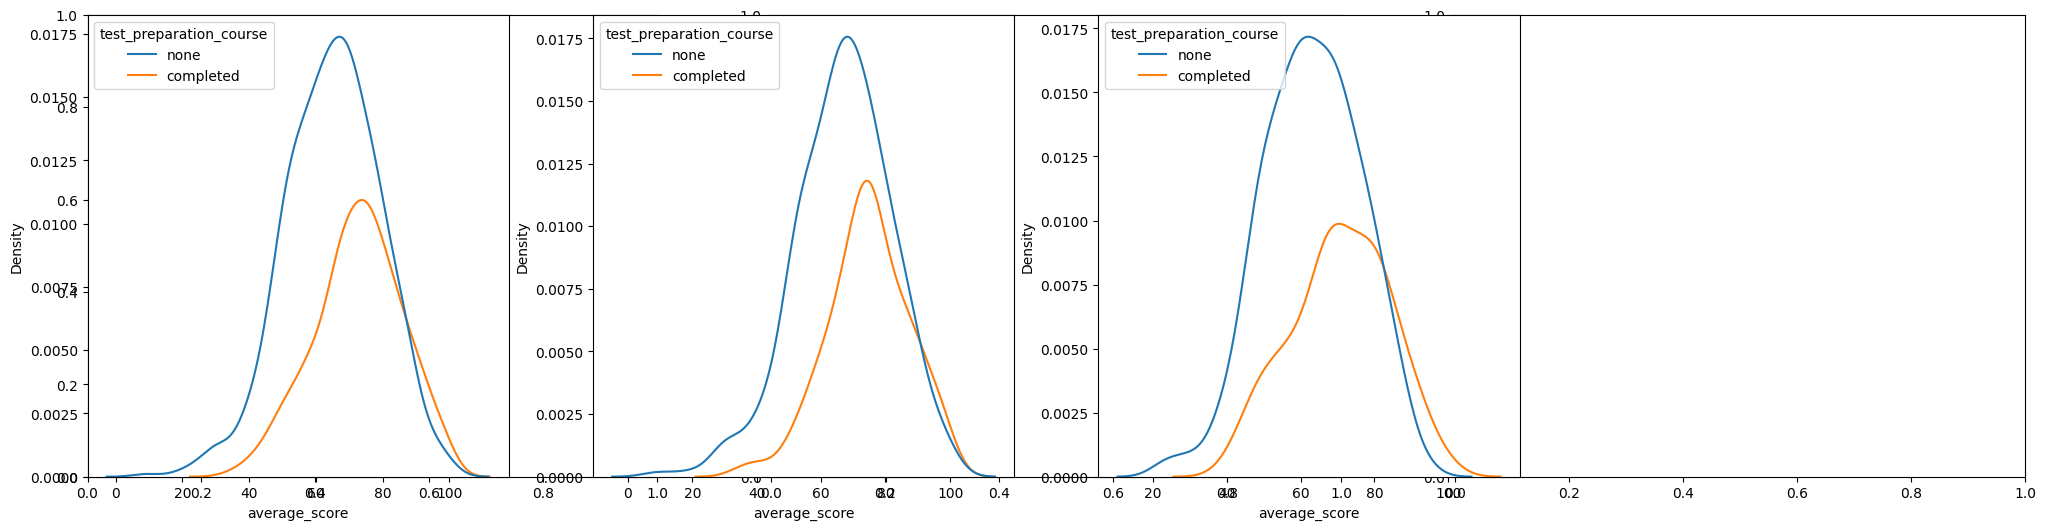

In [ ]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.kdeplot(data=df,x='average_score',hue='test_preparation_course')
plt.subplot(142)
sns.kdeplot(data=df[df.gender=='female'],x='average_score',hue='test_preparation_course')
plt.subplot(143)
sns.kdeplot(data=df[df.gender=='male'],x='average_score',hue='test_preparation_course')
plt.show()

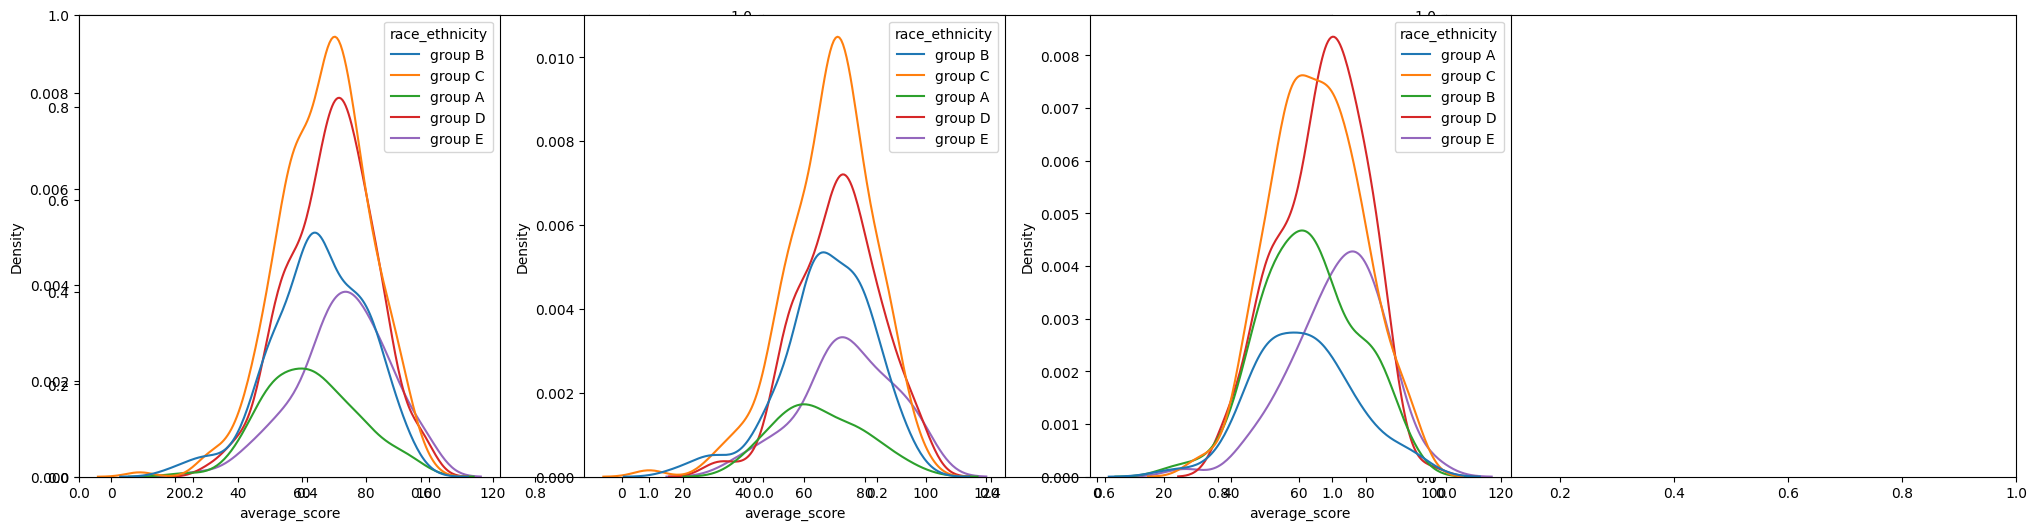

In [62]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.kdeplot(data=df,x='average_score',hue='race_ethnicity')
plt.subplot(142)
sns.kdeplot(data=df[df.gender=='female'],x='average_score',hue='race_ethnicity')
plt.subplot(143)
sns.kdeplot(data=df[df.gender=='male'],x='average_score',hue='race_ethnicity')
plt.show()

**INSIGHTS :-**

1. Group c and d were performing more well in  the tests overall in all categories.
2. Test preparation course has no effect overall on the score 

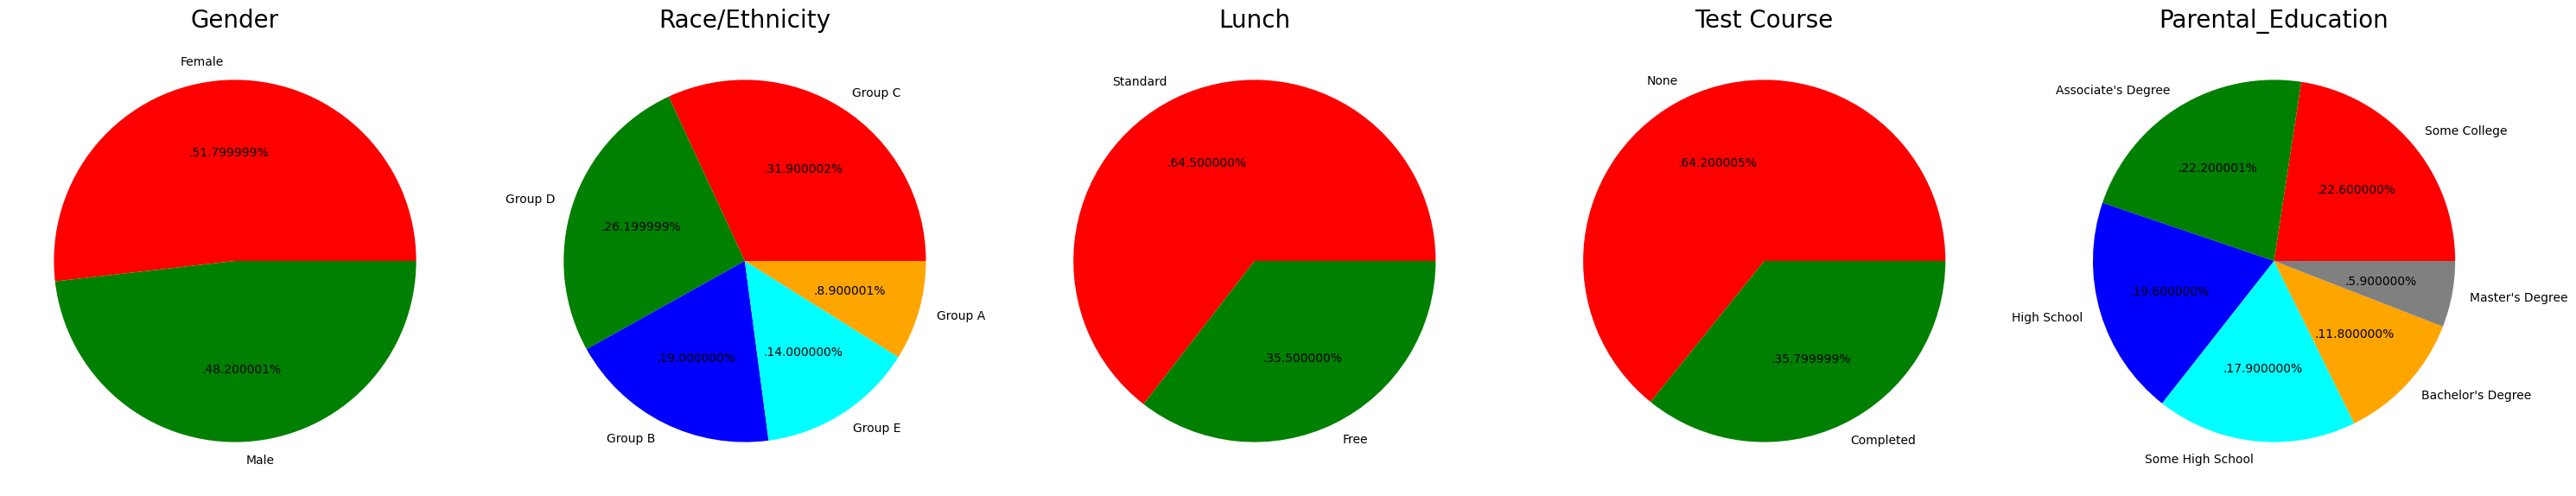

In [ ]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental_Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

**INSIGHTS :-**

1. Male and females are almost in the same number
2. Group C is most dominant race
3. Standard lunch students are in greater quantity
4. No one has taken the test preparation course
5. Most amount of parents are educated from some college or have the associate degree

In [97]:
sns.countplot(data=df, x=df["gender"], ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

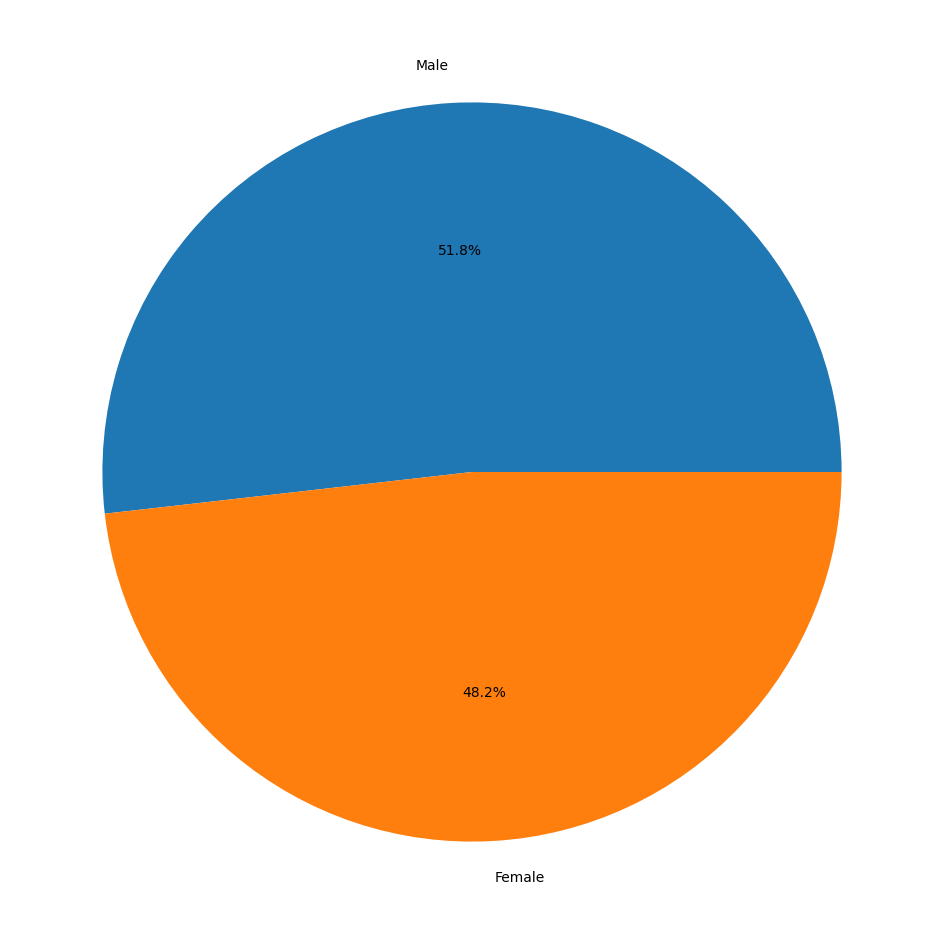

In [76]:
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],autopct='%1.1f%%')
plt.show()

In [78]:
#BIVARIATE ANALYSIS 
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total_score,average_score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


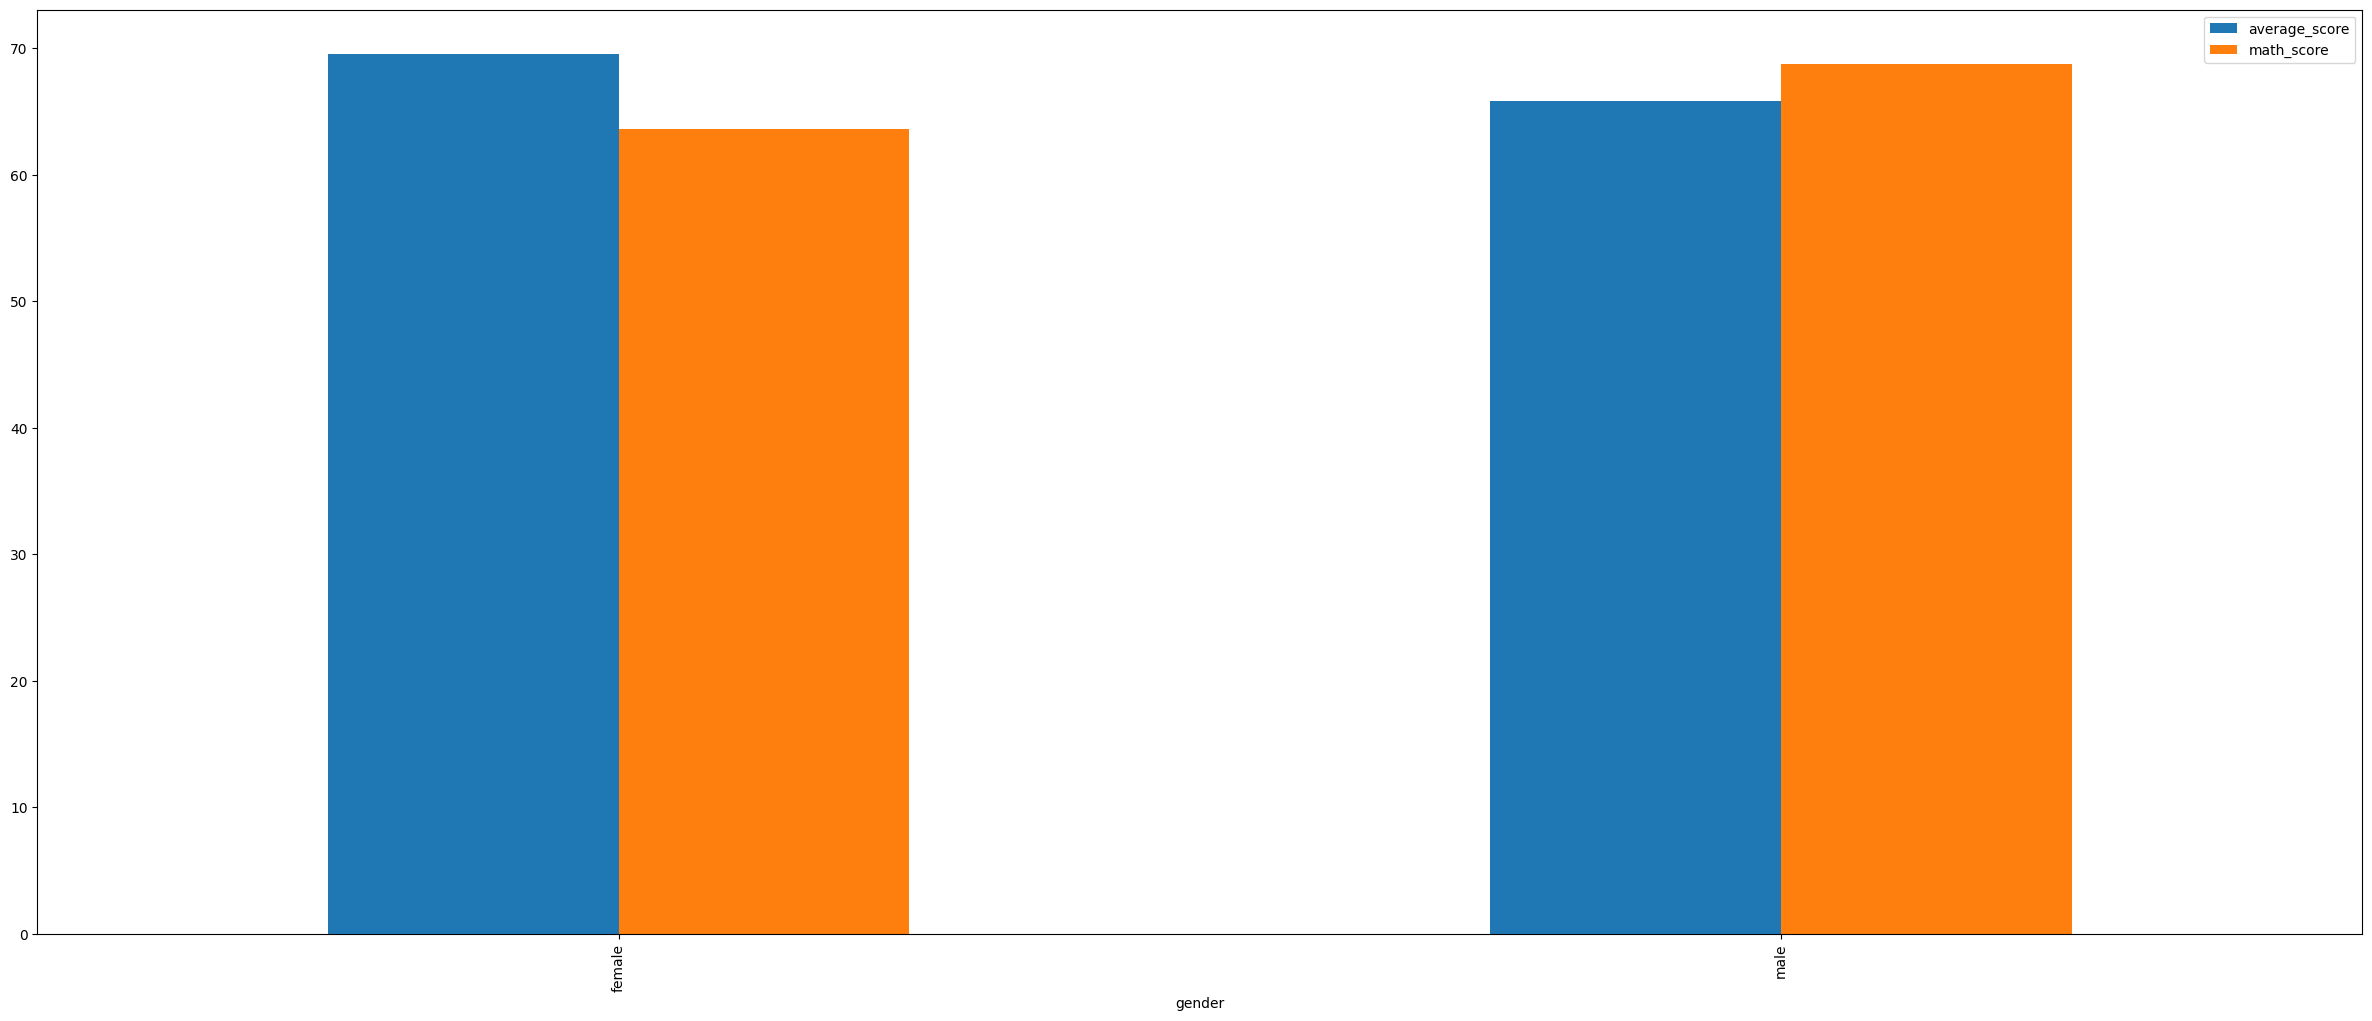

In [85]:
gender_group = df.groupby('gender')[['average_score', 'math_score']].mean().reset_index()

gender_group.plot(x='gender', kind='bar')
plt.show()

**INSIGHTS :-**

1. In maths males have the higher scores than the females
2. While for the average_score the scenario is same

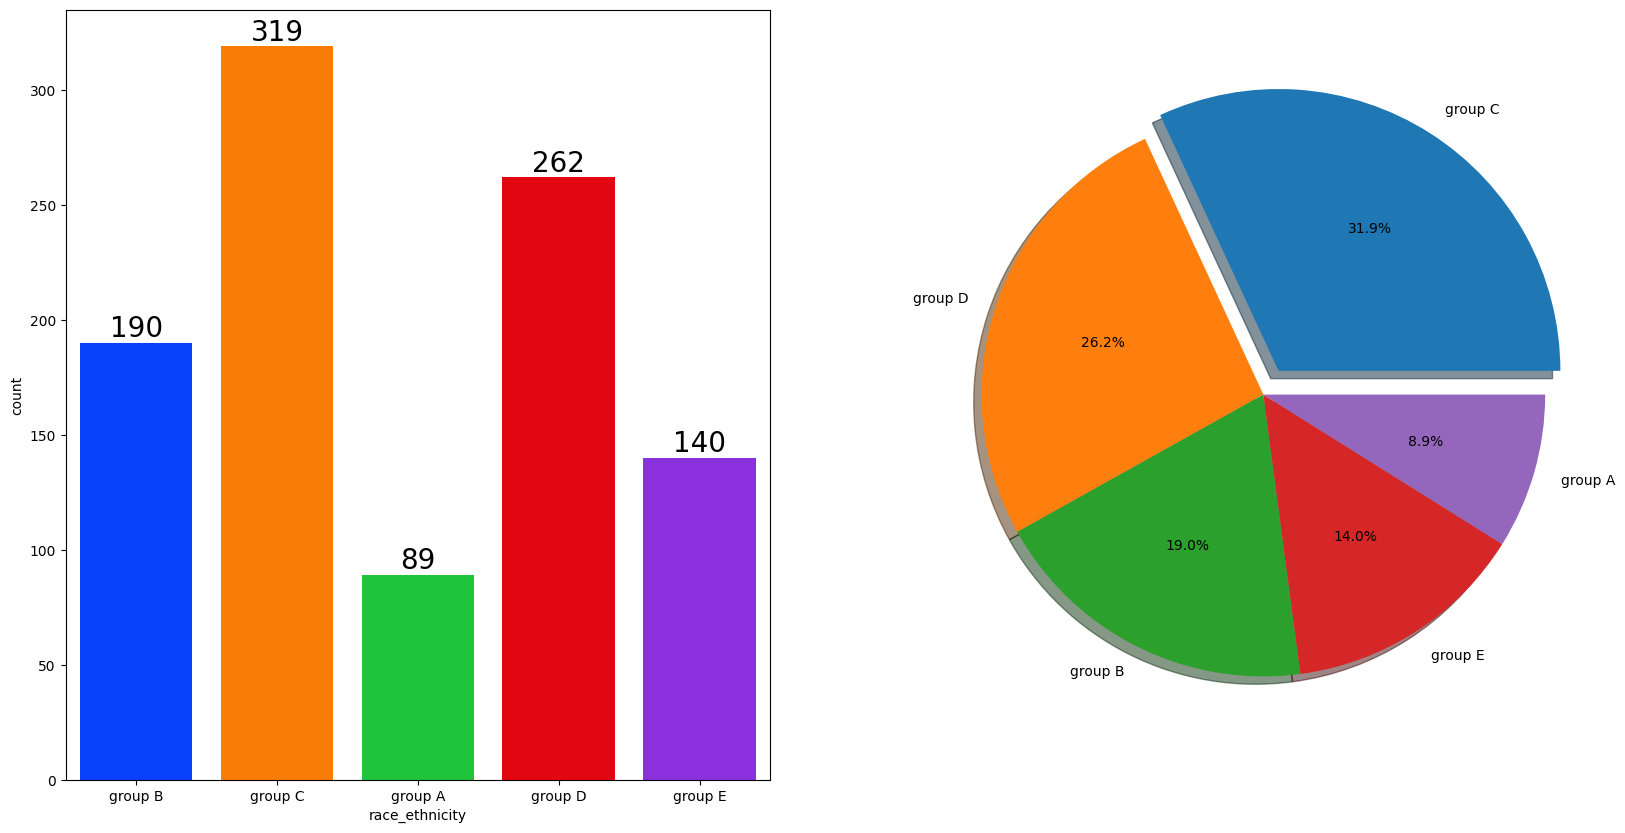

In [91]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show() 

**CHECKING THE OUTLIERS :-**

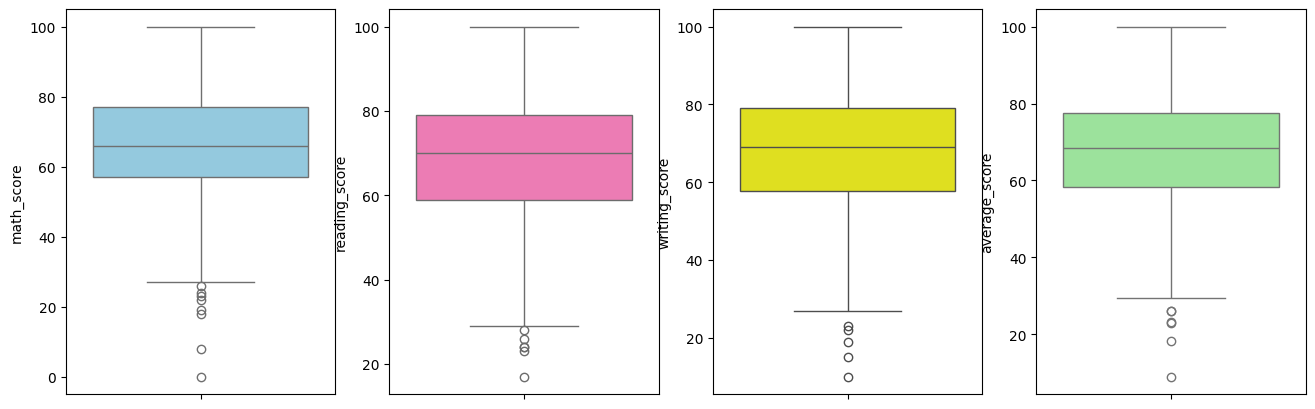

In [93]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

In [94]:
def remove_outliers_iqr(df, columns):
    df = df.copy()
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df = df[
            (df[col] >= lower_bound) & 
            (df[col] <= upper_bound)
        ]
    
    return df

In [95]:
df = remove_outliers_iqr(df, numeric_features)

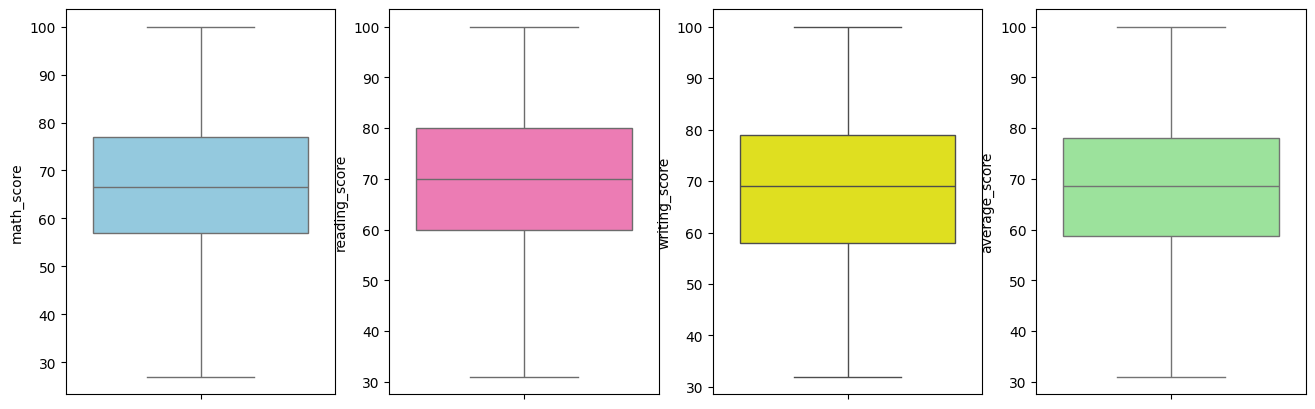

In [96]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()